# Brain and interactive visualizations

Use fictitious coordinates to demonstrate glass-brain and Plotly views. Surface recipes are kept opt-in because they require large template assets.

All signals, labels, and coordinates in this notebook are deterministic and
synthetic. They do not represent a participant. Run cells from top to bottom.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

In [2]:
epochs = make_epochs(n_trials=10)
edges = make_edges()
metadata = make_electrode_metadata()
metrics = make_metric_table()

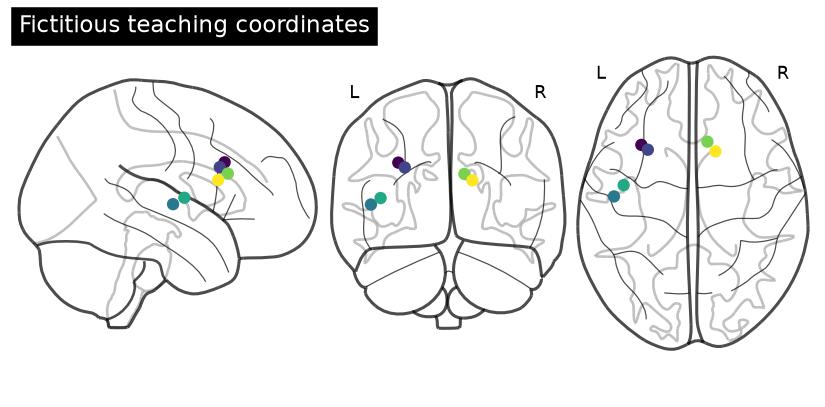

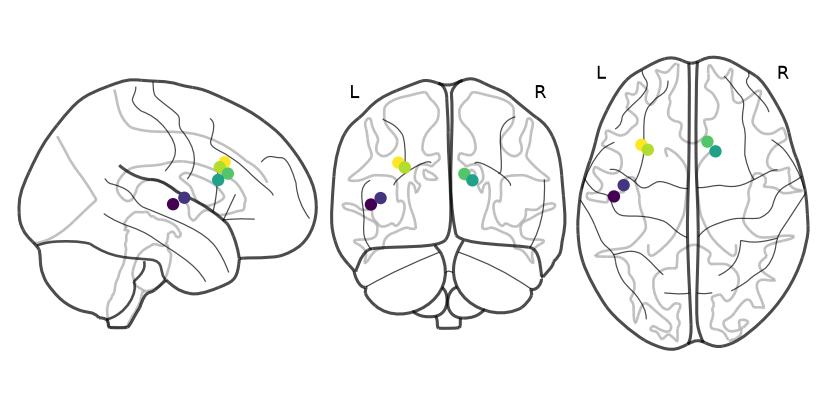

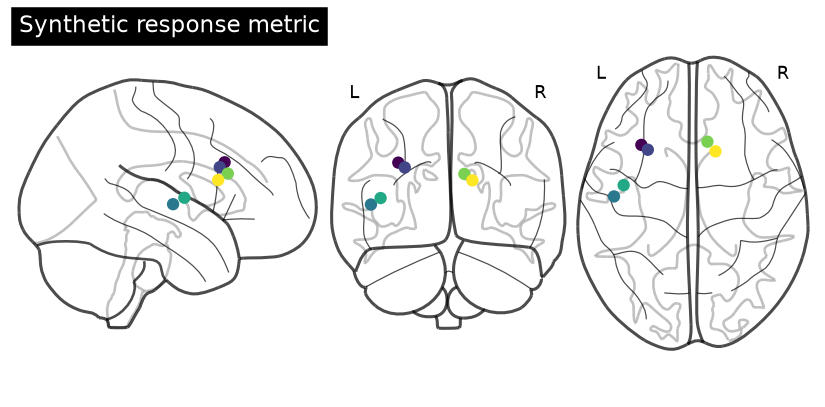

In [3]:
display = viz.plot_electrode_mni(
    metadata[["mni_x", "mni_y", "mni_z"]].to_numpy(),
    values=np.linspace(0.2, 1.0, len(metadata)),
    title="Fictitious teaching coordinates",
)
plt.show()

display = viz.plot_electrodes_from_metadata(metadata, value_col="mni_z")
plt.show()

metric = pd.Series(np.linspace(0.1, 1.0, len(metadata)), index=metadata.elec_label)
display = viz.plot_erps_on_brain(metadata, metric, title="Synthetic response metric")
plt.show()

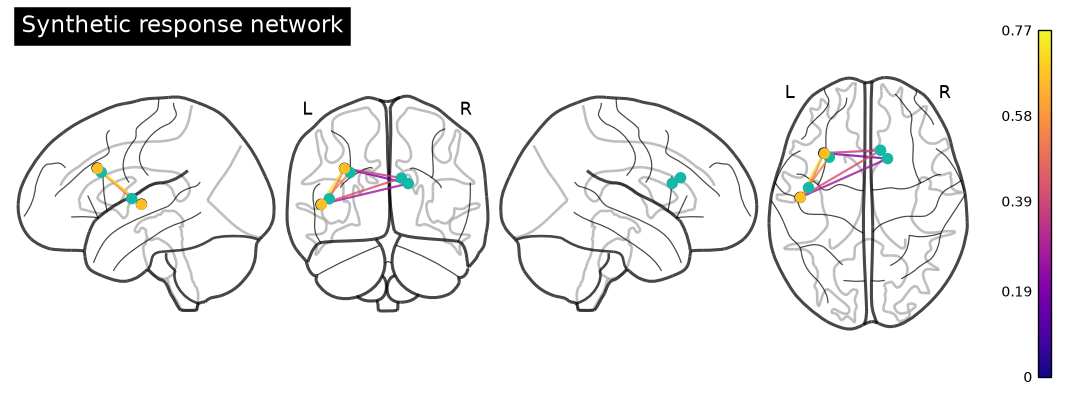

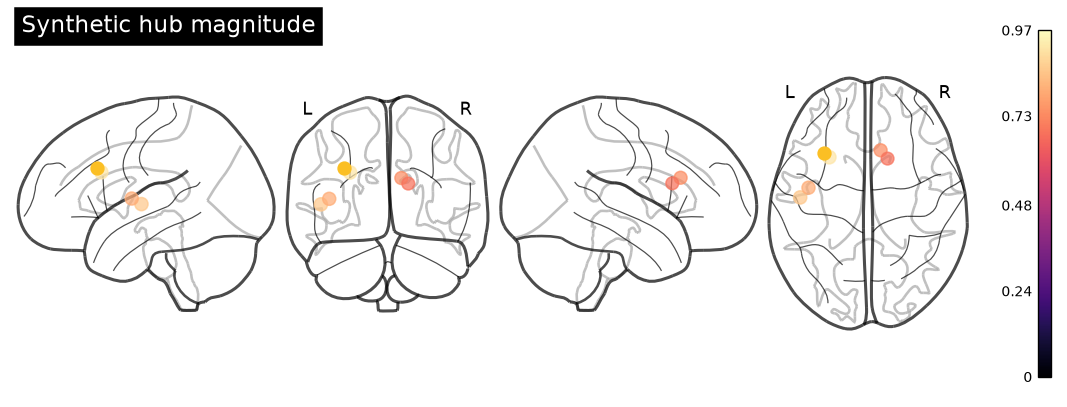

In [4]:
display = viz.plot_glass_brain_network(
    edges, metadata, validate_mni=False, title="Synthetic response network"
)
plt.show()

display = viz.plot_node_metric_glass_brain(
    metrics, metadata, metric="hub", validate_mni=False,
    stimulation_nodes=["STIM_A1"], title="Synthetic hub magnitude"
)
plt.show()

Figure 9 animation frames


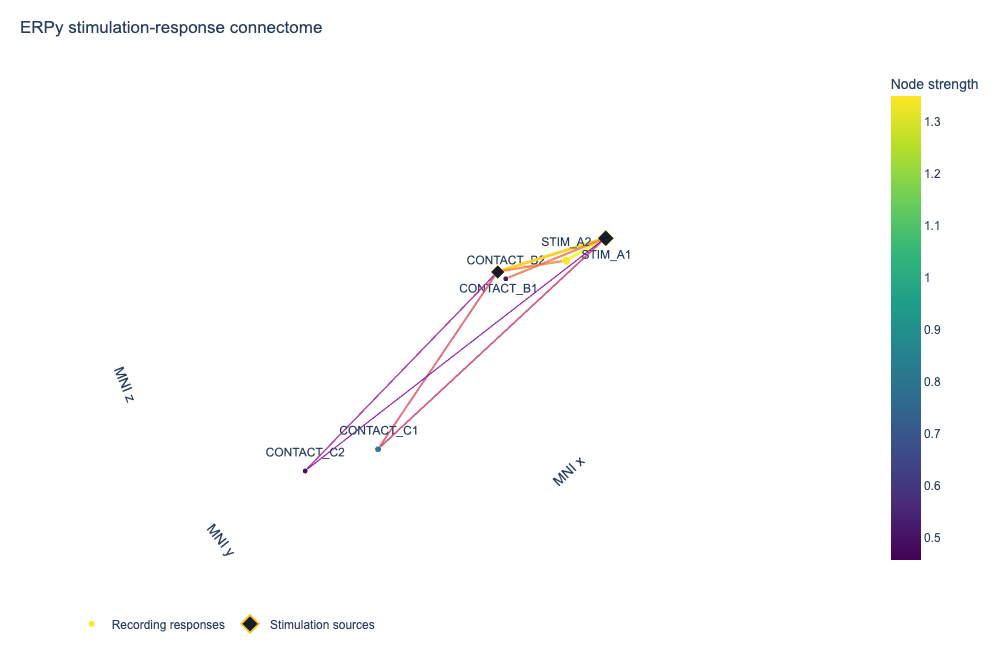

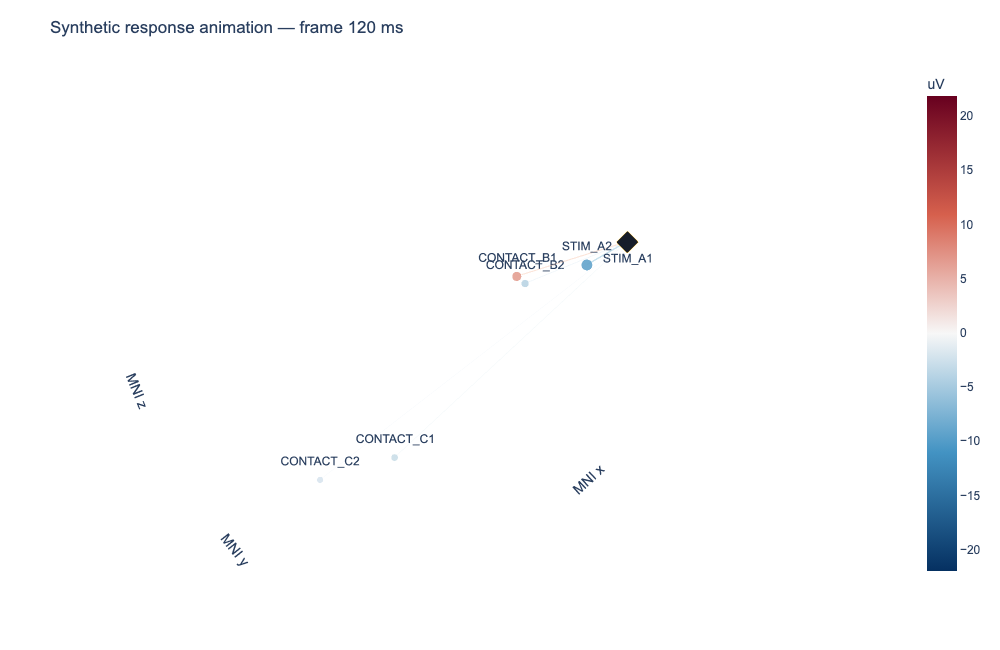

In [5]:
# GitHub cannot run Plotly JavaScript. Save faithful PNG snapshots of the
# generated figures; call interactive.show() or animated.show() in Jupyter
# to rotate the connectome or play the complete animation.
interactive = viz.plot_interactive_connectome(
    edges, metadata, show_brain_shell=False, validate_mni=False
)
animated = viz.plot_evoked_response_graph(
    epochs, metadata, stim_pair="STIM_A_1_2", channels=epochs.channels,
    show_brain_shell=False, validate_mni=False, top_n=6, frame_step_ms=40
)
print(type(interactive).__name__, len(animated.frames), "animation frames")
show_plotly_snapshot(interactive)

# Show a response-period frame, with the original animation data and layout.
import plotly.graph_objects as go
frame_index = min(3, len(animated.frames) - 1)
frame = animated.frames[frame_index]
snapshot = go.Figure(animated)
for index, trace in zip(frame.traces or range(len(frame.data)), frame.data):
    snapshot.data[index].update(trace)
snapshot.update_layout(sliders=[], updatemenus=[], title=f"Synthetic response animation — frame {frame.name}")
show_plotly_snapshot(snapshot)

31 aggregate animation frames


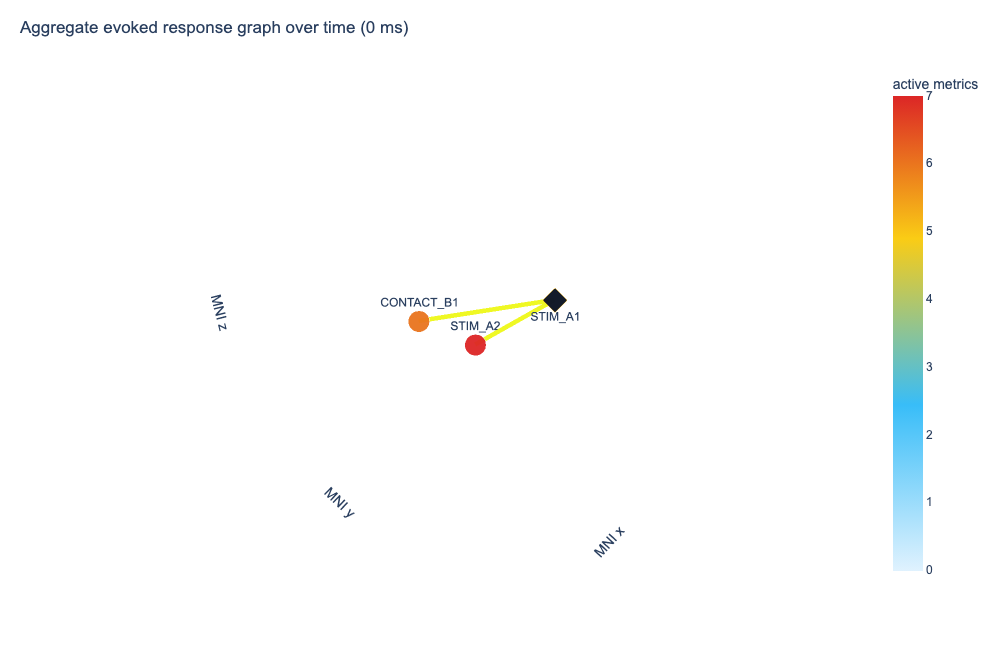

In [6]:
# These renderers need template surfaces and, for `plot_surface_connectome`,
# a local FreeSurfer subjects directory. They are opt-in by design.
RUN_SURFACE_RECIPES = False
if RUN_SURFACE_RECIPES:
    template = viz.plot_template_brain_network(edges, metadata)
    node_template = viz.plot_node_metric_template_brain(metrics, metadata, metric="hub")
    region = viz.plot_region_connectome(edges, metadata)
    electrode = viz.plot_electrode_connectome(
        viz.adjacency_from_edges(edges), metadata
    )
    surface = viz.plot_surface_connectome(
        edges, metadata, subjects_dir=Path("freesurfer_subjects")
    )

# For pooled runs, provide dictionaries containing epochs, detections, and a
# stimulation label, then build one multi-source animation:
RUN_AGGREGATE_RECIPE = True
if RUN_AGGREGATE_RECIPE:
    runs = [{
        "epochs": epochs,
        "stim_pair": "STIM_A_1_2",
        "detections": make_detection_table(epochs),
    }]
    aggregate = viz.plot_aggregate_evoked_response_graph(
        runs, metadata, show_brain_shell=False, validate_mni=False
    )
    print(len(aggregate.frames), "aggregate animation frames")
    show_plotly_snapshot(aggregate)